In [1]:
# STEP 1: Define the State
# The State is a container that carries information through the graph.
from typing_extensions import TypedDict

class State(TypedDict):
    study_plan: str

In [2]:
# STEP 2: Define the Nodes
# Each node is a function that updates the state.

# Node 1

def start_study(state: State):
    print("Start_Study node has been called")
    return {"study_plan": state['study_plan'] + " I am starting my study session."}

# Node 2

def math(state: State):
    print("Math node has been called")
    return {"study_plan": state['study_plan'] + " Focus on Math today."}

# Node 3

def science(state: State):
    print("Science node has been called")
    return {"study_plan": state['study_plan'] + " Focus on Science today."}


In [3]:
# STEP 3: Conditional Logic
# This function decides whether the student studies Math or Science.
import random
from typing import Literal

def random_subject(state: State) -> Literal['math','science']:
    if random.random() > 0.5:
        return "math"
    else:
        return "science"

In [5]:
# STEP 4: Build the LangGraph
# Create the graph, add nodes, and connect them with edges.
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

# Add nodes
graph.add_node("start_study", start_study)
graph.add_node("math", math)
graph.add_node("science", science)

In [6]:
# Define edges
graph.add_edge(START, "start_study")
graph.add_conditional_edges("start_study", random_subject)
graph.add_edge("math", END)
graph.add_edge("science", END)

In [7]:
# STEP 5: Compile the Graph
# Turn the abstract design into a runnable agent.
graph_builder = graph.compile()

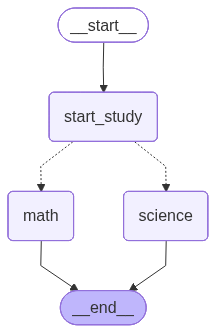

In [8]:
# STEP 6: Visualize the Graph
# Display the graph as a flowchart (Mermaid diagram).
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
# STEP 7: Execute the Graph
# Run the graph with an initial state.
graph_builder.invoke({"study_plan": "Hello, I am a student."})

Start_Study node has been called
Math node has been called


{'study_plan': 'Hello, I am a student. I am starting my study session. Focus on Math today.'}